# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [141]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import geopandas as gpd


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [142]:
# Load data
data = pd.read_csv('data/bcn_noise_ml_filtered.csv')
print(data)

                      road_id  noise_day  noise_evening  noise_night  \
0     2501123851_3587720087_0         65             60           55   
1         30295335_30295334_0         70             65           60   
2        60969463_415941159_0         70             65           65   
3       364997573_364997570_0         70             65           60   
4     2501701062_2501701155_0         70             65           65   
...                       ...        ...            ...          ...   
2312    481122454_478875365_0         50             50           45   
2313   597933817_4318426016_0         45             45           40   
2314   4318426016_597933817_0         45             45           40   
2315    8412738278_30688836_0         50             50           45   
2316    416116751_416116752_0         35             35           35   

      road_length  road_category  dist_to_main  signals  transport   pois  \
0          60.357              5       408.552    1.658   

In [143]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2317 entries, 0 to 2316
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          2317 non-null   str    
 1   noise_day        2317 non-null   int64  
 2   noise_evening    2317 non-null   int64  
 3   noise_night      2317 non-null   int64  
 4   road_length      2317 non-null   float64
 5   road_category    2317 non-null   int64  
 6   dist_to_main     2317 non-null   float64
 7   signals          2317 non-null   float64
 8   transport        2317 non-null   float64
 9   pois             2317 non-null   float64
 10  width            2317 non-null   float64
 11  height           2317 non-null   float64
 12  betw_centrality  2317 non-null   float64
 13  clos_centrality  2317 non-null   float64
 14  green_100        2317 non-null   float64
dtypes: float64(10), int64(4), str(1)
memory usage: 271.7 KB


## Predicting Street-level Noise


### Select features (X)

In [ ]:
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night','transport']) # keep only features
X

,road_length,dist_to_main,signals,pois,width,height,betw_centrality,clos_centrality,green_100
0,60.357,408.552,1.658,44.774,6.966,8.333,0.005,0.000,7.176
1,94.719,194.282,2.114,1.057,13.837,4.833,0.000,0.000,0.000
2,78.531,235.864,2.547,14.010,16.957,10.167,0.008,0.000,0.120
3,42.799,265.783,2.335,2.335,0.000,0.000,0.000,0.000,1.245
4,130.428,20.756,3.068,17.640,7.914,7.440,0.000,0.000,1.115
...,...,...,...,...,...,...,...,...,...
2312,155.526,0.000,2.577,3.866,50.000,0.000,0.000,0.000,120.231
2313,16.851,332.572,5.936,5.936,50.000,0.000,0.004,0.000,45.646
2314,16.851,332.572,5.936,5.936,50.000,0.000,0.004,0.000,45.646
2315,23.555,0.857,4.253,4.253,36.866,6.000,0.000,0.000,27.350


### Standard scaling

In [145]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

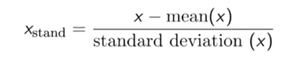

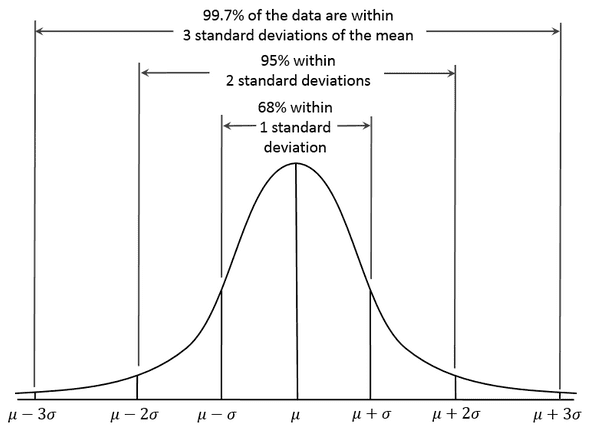

In [146]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.30673512,  1.29568155, -0.47336228, ...,  0.01431759,
         0.36811214, -0.11939689],
       [-0.0860679 ,  0.12160416, -0.42784914, ..., -0.46746807,
         0.77348931, -0.41702453],
       [-0.19002208,  0.34945006, -0.38466995, ...,  0.36916682,
         1.58539133, -0.41203356],
       ...,
       [-0.58612262,  0.87935335, -0.04653686, ..., -0.04886728,
        -0.05451524,  1.47610256],
       [-0.54307094, -0.9382489 , -0.21452786, ..., -0.46499121,
         0.96749113,  0.71729364],
       [-0.15593967, -0.86600241, -0.51992349, ..., -0.39531564,
        -2.11590998, -0.41702453]], shape=(2317, 9))

In [147]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(2317, 9)
             0        1        2        3        4        5        6        7  \
count 2317.000 2317.000 2317.000 2317.000 2317.000 2317.000 2317.000 2317.000   
mean    -0.000   -0.000    0.000   -0.000    0.000    0.000   -0.000    0.000   
std      1.000    1.000    1.000    1.000    1.000    1.000    1.000    1.000   
min     -0.688   -0.943   -0.636   -0.740   -1.947   -1.291   -0.519   -3.228   
25%     -0.426   -0.943   -0.505   -0.639   -0.823   -0.747   -0.492   -0.508   
50%     -0.187   -0.232   -0.347   -0.433   -0.154   -0.155   -0.397    0.070   
75%      0.156    0.537   -0.017    0.161    0.820    0.602   -0.019    0.723   
max     19.218    4.873    4.350    3.168    1.530    3.441    9.367    1.591   

             8  
count 2317.000  
mean     0.000  
std      1.000  
min     -0.417  
25%     -0.417  
50%     -0.390  
75%     -0.015  
max     12.222  


### Define dependant variable (Y)

In [148]:
# Define the dependant variable / target to predict
y_reg = data.noise_day
print(y_reg)

0       65
1       70
2       70
3       70
4       70
        ..
2312    50
2313    45
2314    45
2315    50
2316    35
Name: noise_day, Length: 2317, dtype: int64


### Split data

In [149]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [150]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(1853, 9)
(1853,)
(464, 9)
(464,)


## Linear Regression

### Train model

In [151]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

score_linear = model.score(X_test, y_test)

print("Before removing outliers: score 0.38")


0.38490257893310775
0.3153199946439722
Before removing outliers: score 0.38


In [152]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [ 0.74633659 -1.84602309  0.89903648  0.31057253  1.35078156  0.49788587
  0.90296177  2.23095006 -0.82258854] intercetp 59.35198107686761


### Inspect results

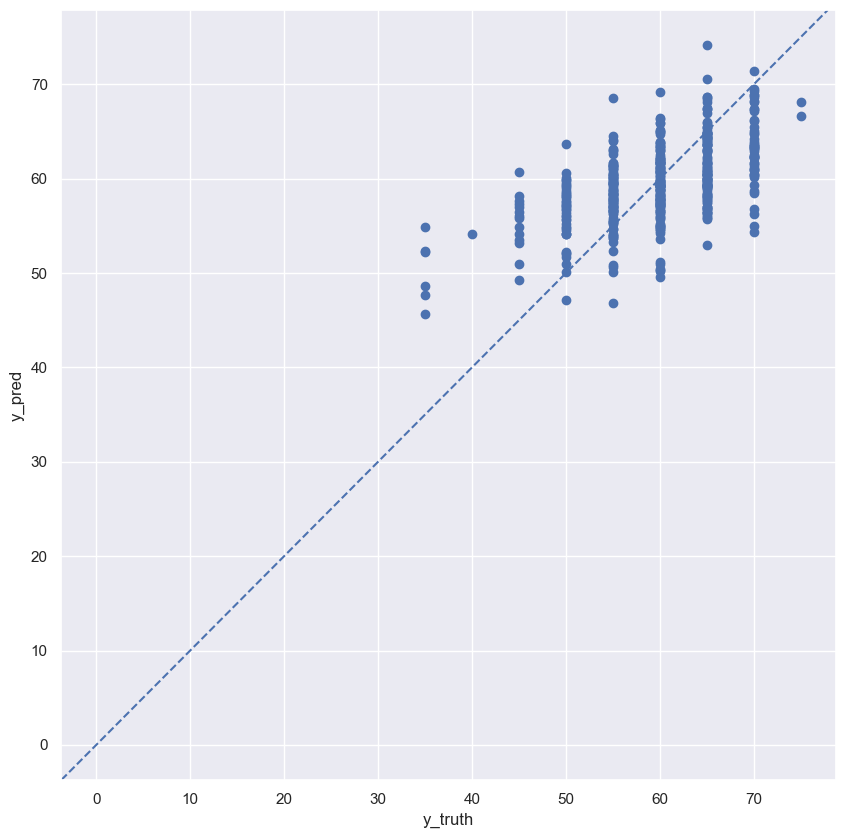

In [153]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_reg'] = y_test - y_pred
plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [154]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 464 entries, 932 to 1451
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          464 non-null    str    
 1   noise_day        464 non-null    int64  
 2   noise_evening    464 non-null    int64  
 3   noise_night      464 non-null    int64  
 4   road_length      464 non-null    float64
 5   road_category    464 non-null    int64  
 6   dist_to_main     464 non-null    float64
 7   signals          464 non-null    float64
 8   transport        464 non-null    float64
 9   pois             464 non-null    float64
 10  width            464 non-null    float64
 11  height           464 non-null    float64
 12  betw_centrality  464 non-null    float64
 13  clos_centrality  464 non-null    float64
 14  green_100        464 non-null    float64
 15  diff_reg         464 non-null    float64
dtypes: float64(11), int64(4), str(1)
memory usage: 61.6 KB


In [155]:
data_test['noisePred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_reg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main', 'signals']
).interactive()

alt.Chart(...)

## XGBoost

### Train with new model

In [156]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))
score_xgb = model.score(X_test, y_test)
data_test['score_xgb'] = score_xgb

0.9878782629966736
0.3395015001296997


### Inspect results

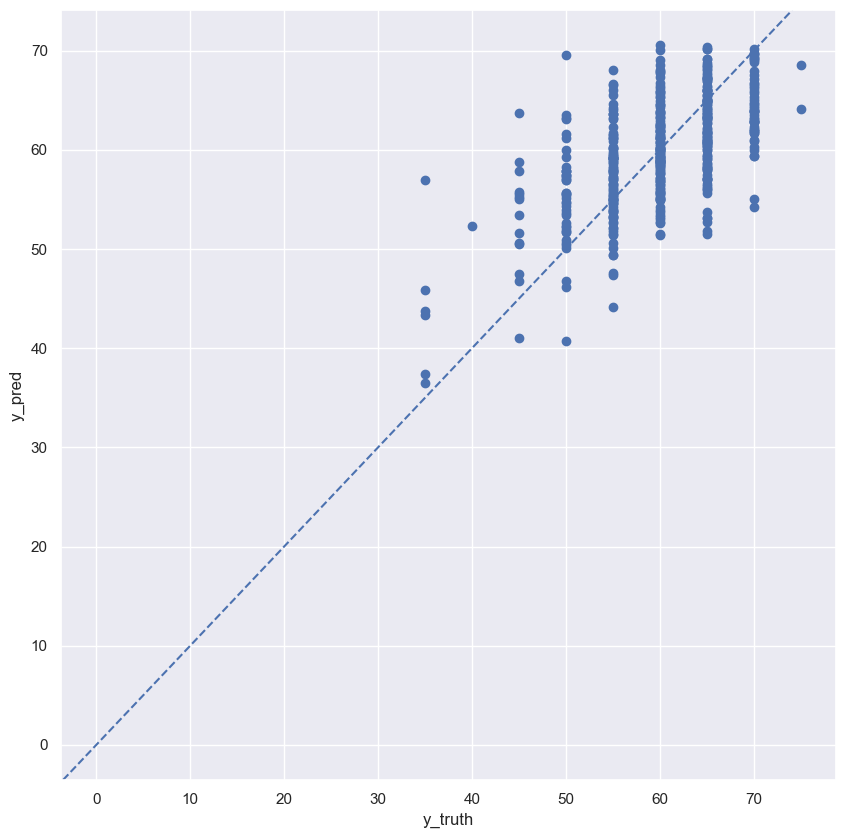

In [157]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_xg'] = y_test - y_pred

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [158]:
data_test['noisePred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main','signals']
).interactive()

alt.Chart(...)

### Compare results

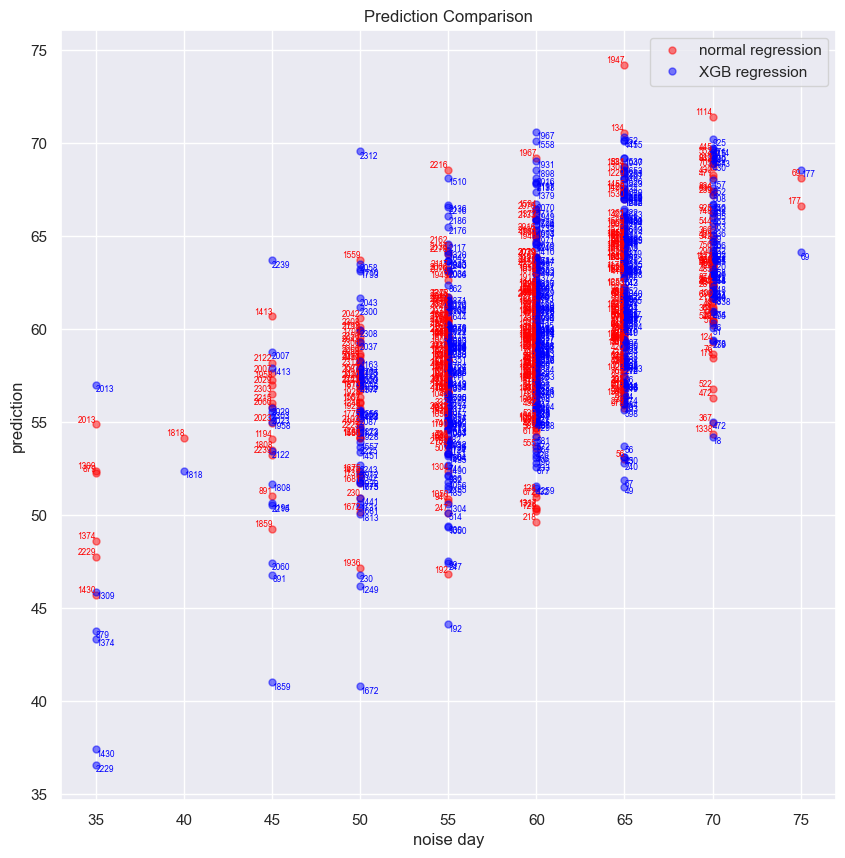

In [159]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('noise day')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()

In [160]:
data_test.shape

(464, 20)